# EDA & Cleaning

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [36]:
plt.rcParams['font.family'] = 'DejaVu Sans'

In [37]:
df = pd.read_csv("social_media_screentime_mental_health_2026.csv")

In [38]:
df.head()

,participant_id,age,gender,occupation,region,most_used_platform,platforms_used_count,daily_screen_hours,daily_notifications,night_time_use,...,life_satisfaction_1to10,loneliness_1to10,self_esteem_1to10,fomo_1to10,social_comparison_1to10,physical_activity_days_per_week,uses_screen_time_limits,attempted_digital_detox,seeks_mental_health_support,wellbeing_band
0,P300000,33,Male,Student,Latin America,TikTok,8,3.2,172,Never,...,9,6,4,6,8,4,No,No,No,At-risk
1,P300001,23,Female,Full-time employed,Oceania,Instagram,8,4.5,38,Often,...,7,5,8,5,8,4,No,"Yes, failed",Yes,At-risk
2,P300002,56,Female,Full-time employed,Africa,Instagram,1,5.3,74,Every night,...,8,7,3,2,3,5,No,No,No,Moderate
3,P300003,13,Male,Student,Europe,YouTube,4,3.4,49,Sometimes,...,10,6,6,1,5,4,No,"Yes, failed",Yes,Moderate
4,P300004,36,Female,Student,Asia,LinkedIn,5,5.8,227,Never,...,4,6,8,7,9,3,Yes,"Yes, succeeded",No,Moderate


In [39]:
df.shape

(7000, 25)

In [40]:
df.isna().sum()

participant_id                           0
age                                      0
gender                                  70
occupation                               0
region                                   0
most_used_platform                       0
platforms_used_count                     0
daily_screen_hours                       0
daily_notifications                      0
night_time_use                           0
minutes_to_first_check_after_waking      0
primary_purpose                          0
avg_sleep_hours                        105
anxiety_score_0to27                      0
low_mood_score_0to27                     0
life_satisfaction_1to10                  0
loneliness_1to10                         0
self_esteem_1to10                        0
fomo_1to10                               0
social_comparison_1to10                  0
physical_activity_days_per_week          0
uses_screen_time_limits                  0
attempted_digital_detox                  0
seeks_menta

In [ ]:
df['avg_sleep_hours'] = df['avg_sleep_hours'].fillna(df['avg_sleep_hours'].mode()[0])
df = df.dropna(subset=['gender'])

In [42]:
df.isna().sum()

participant_id                         0
age                                    0
gender                                 0
occupation                             0
region                                 0
most_used_platform                     0
platforms_used_count                   0
daily_screen_hours                     0
daily_notifications                    0
night_time_use                         0
minutes_to_first_check_after_waking    0
primary_purpose                        0
avg_sleep_hours                        0
anxiety_score_0to27                    0
low_mood_score_0to27                   0
life_satisfaction_1to10                0
loneliness_1to10                       0
self_esteem_1to10                      0
fomo_1to10                             0
social_comparison_1to10                0
physical_activity_days_per_week        0
uses_screen_time_limits                0
attempted_digital_detox                0
seeks_mental_health_support            0
wellbeing_band  

In [43]:
df.duplicated().sum()

np.int64(0)

In [44]:
numeric_cols = ['age', 'daily_screen_hours', 'daily_notifications',
                 'minutes_to_first_check_after_waking', 'avg_sleep_hours',
                 'anxiety_score_0to27', 'low_mood_score_0to27',
                 'life_satisfaction_1to10', 'loneliness_1to10',
                 'self_esteem_1to10', 'fomo_1to10', 'social_comparison_1to10',
                 'physical_activity_days_per_week']

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

outliers

,participant_id,age,gender,occupation,region,most_used_platform,platforms_used_count,daily_screen_hours,daily_notifications,night_time_use,...,life_satisfaction_1to10,loneliness_1to10,self_esteem_1to10,fomo_1to10,social_comparison_1to10,physical_activity_days_per_week,uses_screen_time_limits,attempted_digital_detox,seeks_mental_health_support,wellbeing_band


In [45]:
df.describe()

,age,platforms_used_count,daily_screen_hours,daily_notifications,minutes_to_first_check_after_waking,avg_sleep_hours,anxiety_score_0to27,low_mood_score_0to27,life_satisfaction_1to10,loneliness_1to10,self_esteem_1to10,fomo_1to10,social_comparison_1to10,physical_activity_days_per_week
count,6930.000000,6930.000000,6930.000000,6930.000000,6930.000000,6930.000000,6930.000000,6930.000000,6930.000000,6930.000000,6930.000000,6930.000000,6930.000000,6930.000000
mean,29.250072,3.495382,3.305815,61.552092,20.038817,6.965051,11.375469,3.851515,6.955267,4.684127,6.003030,4.641270,5.326118,2.803319
std,9.573361,1.761438,1.882597,54.969318,13.984676,0.865422,4.779403,3.538711,1.616150,2.094449,1.886173,2.158605,2.089462,1.287333
min,13.000000,1.000000,0.200000,5.000000,0.000000,3.800000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000
25%,22.000000,2.000000,1.900000,23.000000,10.000000,6.400000,8.000000,0.000000,6.000000,3.000000,5.000000,3.000000,4.000000,2.000000
50%,29.000000,3.000000,3.000000,46.000000,17.000000,7.000000,11.000000,3.000000,7.000000,5.000000,6.000000,5.000000,5.000000,3.000000
75%,36.000000,5.000000,4.300000,83.000000,27.000000,7.500000,14.000000,6.000000,8.000000,6.000000,7.000000,6.000000,7.000000,4.000000
max,71.000000,8.000000,14.000000,400.000000,111.000000,10.000000,27.000000,19.000000,10.000000,10.000000,10.000000,10.000000,10.000000,7.000000


# Visualization

C:\Users\lenovo\AppData\Local\Temp\ipykernel_22328\53867601.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby('screen_bin')[['anxiety_score_0to27','life_satisfaction_1to10','avg_sleep_hours']].mean()


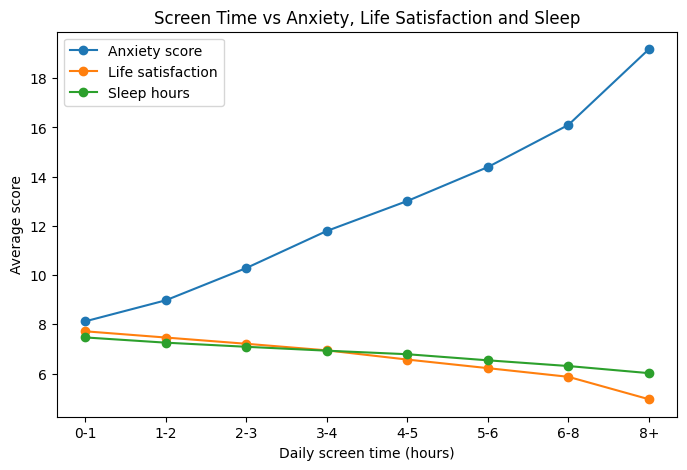

In [46]:
bins = [0,1,2,3,4,5,6,8,20]
labels = ['0-1','1-2','2-3','3-4','4-5','5-6','6-8','8+']
df['screen_bin'] = pd.cut(df['daily_screen_hours'], bins=bins, labels=labels)

grouped = df.groupby('screen_bin')[['anxiety_score_0to27','life_satisfaction_1to10','avg_sleep_hours']].mean()

plt.figure(figsize=(8,5))
plt.plot(grouped.index, grouped['anxiety_score_0to27'], marker='o', label='Anxiety score')
plt.plot(grouped.index, grouped['life_satisfaction_1to10'], marker='o', label='Life satisfaction')
plt.plot(grouped.index, grouped['avg_sleep_hours'], marker='o', label='Sleep hours')
plt.xlabel('Daily screen time (hours)')
plt.ylabel('Average score')
plt.title('Screen Time vs Anxiety, Life Satisfaction and Sleep')
plt.legend()
plt.show()

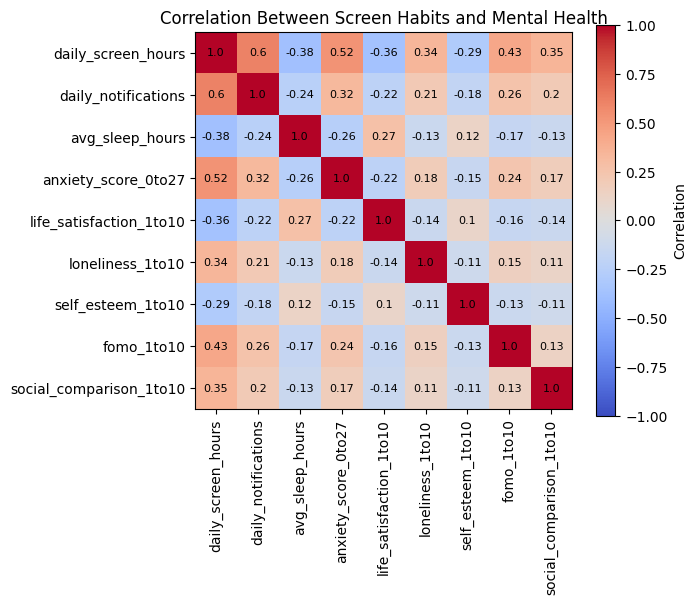

In [47]:
cols = ['daily_screen_hours','daily_notifications','avg_sleep_hours',
        'anxiety_score_0to27','life_satisfaction_1to10','loneliness_1to10',
        'self_esteem_1to10','fomo_1to10','social_comparison_1to10']

corr = df[cols].corr()

plt.figure(figsize=(7,6))
plt.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
plt.xticks(range(len(cols)), cols, rotation=90)
plt.yticks(range(len(cols)), cols)
plt.colorbar(label='Correlation')

# add the numbers on each square
for i in range(len(cols)):
    for j in range(len(cols)):
        plt.text(j, i, round(corr.iloc[i, j], 2),
                  ha='center', va='center', color='black', fontsize=8)

plt.title('Correlation Between Screen Habits and Mental Health')
plt.tight_layout()
plt.show()

C:\Users\lenovo\AppData\Local\Temp\ipykernel_22328\3135503745.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped2 = df.groupby('notif_bin')[['anxiety_score_0to27','fomo_1to10']].mean()


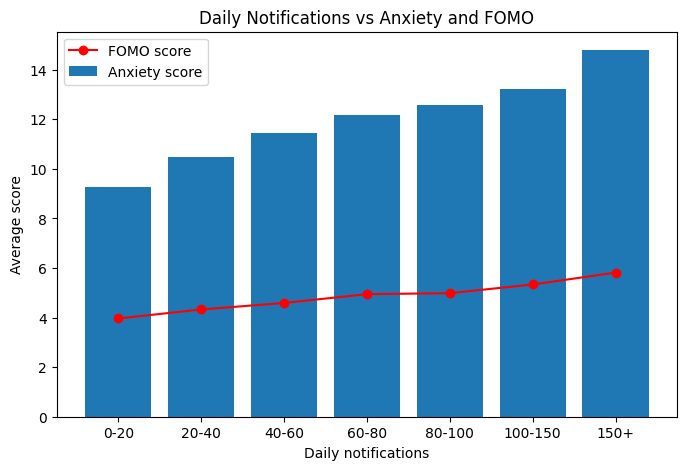

In [48]:
bins = [0,20,40,60,80,100,150,300]
labels = ['0-20','20-40','40-60','60-80','80-100','100-150','150+']
df['notif_bin'] = pd.cut(df['daily_notifications'], bins=bins, labels=labels)

grouped2 = df.groupby('notif_bin')[['anxiety_score_0to27','fomo_1to10']].mean()

plt.figure(figsize=(8,5))
plt.bar(grouped2.index, grouped2['anxiety_score_0to27'], label='Anxiety score')
plt.plot(grouped2.index, grouped2['fomo_1to10'], marker='o', color='red', label='FOMO score')
plt.xlabel('Daily notifications')
plt.ylabel('Average score')
plt.title('Daily Notifications vs Anxiety and FOMO')
plt.legend()
plt.show()

C:\Users\lenovo\AppData\Local\Temp\ipykernel_22328\2031889687.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


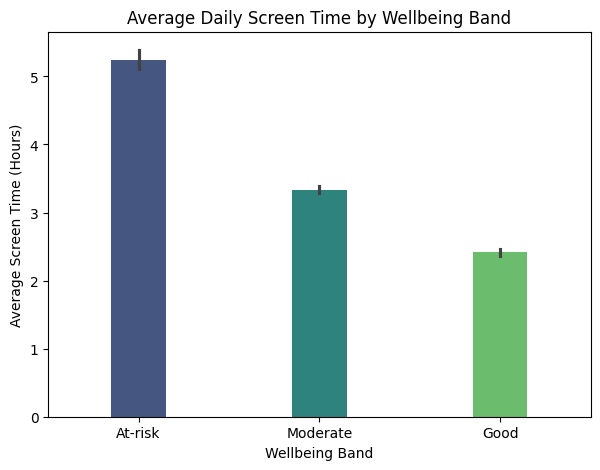

In [59]:


plt.figure(figsize=(7,5))

sns.barplot(
    data=df,
    x='wellbeing_band',
    y='daily_screen_hours',
    estimator='mean',
    palette='viridis',
    width = 0.3
)

plt.title("Average Daily Screen Time by Wellbeing Band")
plt.xlabel("Wellbeing Band")
plt.ylabel("Average Screen Time (Hours)")
plt.show()

C:\Users\lenovo\AppData\Local\Temp\ipykernel_22328\3289781977.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


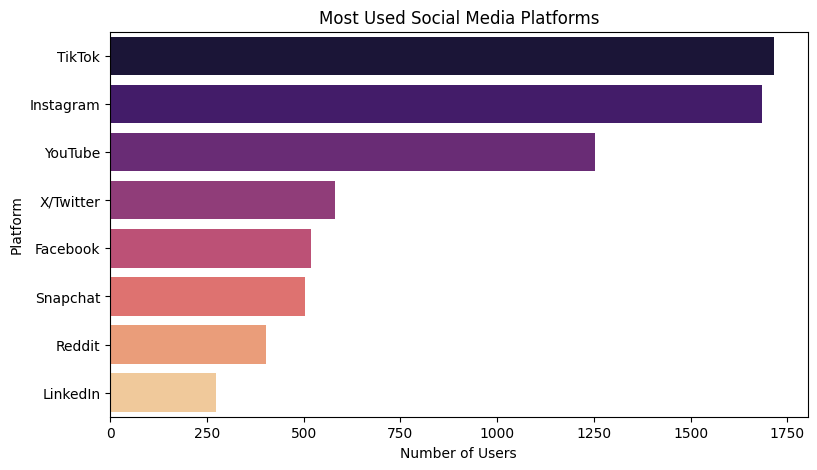

In [57]:
plt.figure(figsize=(9,5))

sns.countplot(
    data=df,
    y='most_used_platform',
    order=df['most_used_platform'].value_counts().index,
    palette='magma'
)

plt.title("Most Used Social Media Platforms")
plt.xlabel("Number of Users")
plt.ylabel("Platform")
plt.show()

# Simple Linear Regression Model

In [49]:
encoding = {'At-risk': 0, 'Moderate': 1, 'Good': 2}
df['wellbeing_band_encoded'] = df['wellbeing_band'].map(encoding)

In [55]:
df.head(10)

,participant_id,age,gender,occupation,region,most_used_platform,platforms_used_count,daily_screen_hours,daily_notifications,night_time_use,...,fomo_1to10,social_comparison_1to10,physical_activity_days_per_week,uses_screen_time_limits,attempted_digital_detox,seeks_mental_health_support,wellbeing_band,screen_bin,notif_bin,wellbeing_band_encoded
0,P300000,33,Male,Student,Latin America,TikTok,8,3.2,172,Never,...,6,8,4,No,No,No,At-risk,3-4,150+,0
1,P300001,23,Female,Full-time employed,Oceania,Instagram,8,4.5,38,Often,...,5,8,4,No,"Yes, failed",Yes,At-risk,4-5,20-40,0
2,P300002,56,Female,Full-time employed,Africa,Instagram,1,5.3,74,Every night,...,2,3,5,No,No,No,Moderate,5-6,60-80,1
3,P300003,13,Male,Student,Europe,YouTube,4,3.4,49,Sometimes,...,1,5,4,No,"Yes, failed",Yes,Moderate,3-4,40-60,1
4,P300004,36,Female,Student,Asia,LinkedIn,5,5.8,227,Never,...,7,9,3,Yes,"Yes, succeeded",No,Moderate,5-6,150+,1
5,P300005,28,Female,Full-time employed,Latin America,YouTube,5,3.6,29,Every night,...,4,3,3,No,No,Yes,Good,3-4,20-40,2
6,P300006,25,Female,Full-time employed,Oceania,Instagram,6,3.5,55,Sometimes,...,7,3,3,No,"Yes, failed",No,Moderate,3-4,40-60,1
7,P300007,40,Female,Part-time employed,Europe,Instagram,2,2.0,10,Never,...,4,7,3,No,"Yes, failed",No,Good,1-2,0-20,2
8,P300008,13,Male,Full-time employed,Europe,X/Twitter,1,4.2,106,Sometimes,...,4,10,4,No,No,Yes,Moderate,4-5,100-150,1
9,P300009,19,Male,Student,Asia,TikTok,1,2.0,34,Every night,...,6,7,0,No,"Yes, succeeded",No,Moderate,1-2,20-40,1


In [51]:
numeric_cols = df.select_dtypes(include='number').columns.tolist()
numeric_cols.remove('wellbeing_band_encoded')

correlations = df[numeric_cols + ['wellbeing_band_encoded']].corr()['wellbeing_band_encoded'].drop('wellbeing_band_encoded')
correlations = correlations.sort_values(key=abs, ascending=False)

correlations


anxiety_score_0to27                   -0.858189
daily_screen_hours                    -0.452378
daily_notifications                   -0.276667
avg_sleep_hours                        0.215693
fomo_1to10                            -0.208784
life_satisfaction_1to10                0.193552
social_comparison_1to10               -0.147272
loneliness_1to10                      -0.147015
self_esteem_1to10                      0.129750
low_mood_score_0to27                   0.078419
minutes_to_first_check_after_waking   -0.012263
age                                    0.007688
platforms_used_count                  -0.004701
physical_activity_days_per_week        0.003859
Name: wellbeing_band_encoded, dtype: float64

With daily screen hours

In [52]:
X = df[['daily_screen_hours']]
y = df['wellbeing_band_encoded']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Coefficient:",round(model.coef_[0]),2)
print("Intercept:",round(model.intercept_),2)
print("R² score:",round(r2_score(y_test, y_pred),2))
print("MSE:",round(mean_squared_error(y_test, y_pred),2))

Coefficient: 0 2
Intercept: 2 2
R² score: 0.21
MSE: 0.34


With anxiety_score_0to27

In [53]:
Z = df[['anxiety_score_0to27']]
y = df['wellbeing_band_encoded']

X_train, X_test, y_train, y_test = train_test_split(Z, y, test_size=0.2, random_state=42)
model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Coefficient:",round( model.coef_[0],2))
print("Intercept:",round(model.intercept_),2)
print("R² score:",round( r2_score(y_test, y_pred),2))
print("MSE:",round(mean_squared_error(y_test, y_pred),2))


Coefficient: -0.12
Intercept: 3 2
R² score: 0.74
MSE: 0.12


# Testing the model

In [54]:

new_anxiety_score = 15

predicted_code = model.predict([[new_anxiety_score]])[0]

if predicted_code <= 0:
    category_name = "Good"     
elif predicted_code <= 1:
    category_name = "Moderate"     
else:
    category_name = "At-risk"        

print(f"Predicted Output: {predicted_code:.2f} ({category_name})")




Predicted Output: 0.76 (Moderate)


C:\Users\lenovo\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
